In [41]:
!uv pip install shap

Audited 1 package in 2ms


In [42]:
!uv pip freeze>requirements.txt

In [43]:
import pandas as pd
import shap

In [44]:
df = pd.read_csv("./data/final_merged_data_rain_plus_crop_yield.csv")

In [45]:
df.head(3)

,District,Year,Crop,Season,Area,Production,Yield,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,...,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Arhar_Tur,Kharif,18800.0,9700.0,0.515957,0.357955,0.357955,0.515957,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Bajra,Kharif,302400.0,243900.0,0.806548,0.557461,0.557461,0.806548,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Castor_seed,Kharif,400.0,100.0,0.250000,0.250000,0.250000,0.250000,...,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [46]:
df.columns

Index(['District', 'Year', 'Crop', 'Season', 'Area', 'Production', 'Yield',
       'Yield_Lag1', 'Yield_Lag2', 'Yield_3yr_Avg', 'Yield_3yr_Std',
       'june_normal_rainfall', 'june_actual_rainfall',
       'june_percent_to_normal', 'july_normal_rainfall',
       'july_actual_rainfall', 'july_percent_to_normal',
       'august_normal_rainfall', 'august_actual_rainfall',
       'august_percent_to_normal', 'september_normal_rainfall',
       'september_actual_rainfall', 'september_percent_to_normal'],
      dtype='str')

In [ ]:
# 1. Rainfall-only model (Strict baseline)

In [47]:
X = df.drop(columns=[
    "Yield",
    "Production",
    "Area",
    "Crop",              # 🚨 REMOVE THIS
    "Yield_Lag1",
    "Yield_Lag2",
    "Yield_3yr_Avg",
    "Yield_3yr_Std"
], errors="ignore")
y = df["Yield"]

In [48]:
X.head(3)

,District,Year,Season,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [49]:
X.head(3)

,District,Year,Season,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [50]:
y.head(3)

0    0.515957
1    0.806548
2    0.250000
Name: Yield, dtype: float64

In [51]:
from sklearn.preprocessing import LabelEncoder

for col in ["Season", "District"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [52]:
X.head(10)

,District,Year,Season,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
3,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
4,0,1998,1,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
5,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
6,0,1998,2,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
7,0,1998,0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
8,0,1998,1,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
9,0,1998,1,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [53]:
X.columns

Index(['District', 'Year', 'Season', 'june_normal_rainfall',
       'june_actual_rainfall', 'june_percent_to_normal',
       'july_normal_rainfall', 'july_actual_rainfall',
       'july_percent_to_normal', 'august_normal_rainfall',
       'august_actual_rainfall', 'august_percent_to_normal',
       'september_normal_rainfall', 'september_actual_rainfall',
       'september_percent_to_normal'],
      dtype='str')

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [56]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("R2:", r2)
print("RMSE:", rmse)

R2: -0.1177874594683177
RMSE: 3.7759906770812206


In [17]:
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

Season                       0.389040
june_percent_to_normal       0.087781
Year                         0.087103
august_percent_to_normal     0.070029
july_actual_rainfall         0.051713
july_percent_to_normal       0.044645
june_actual_rainfall         0.043452
august_actual_rainfall       0.038865
District                     0.036531
september_actual_rainfall    0.032520
dtype: float64


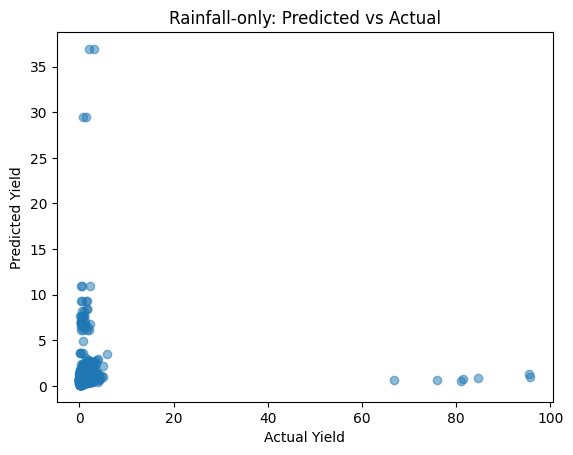

In [57]:
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Rainfall-only: Predicted vs Actual")
plt.show()

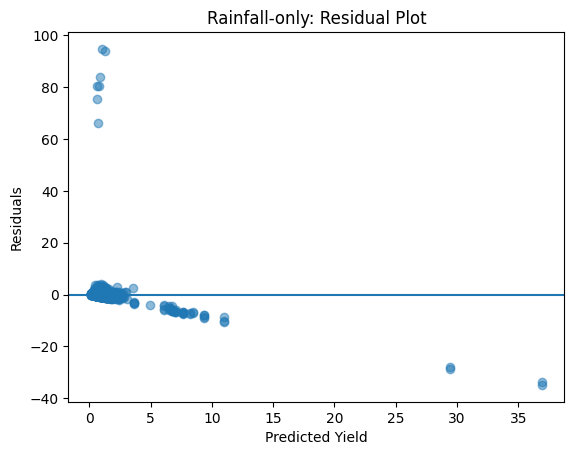

In [58]:
residuals = y_test - preds

plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Rainfall-only: Residual Plot")
plt.show()

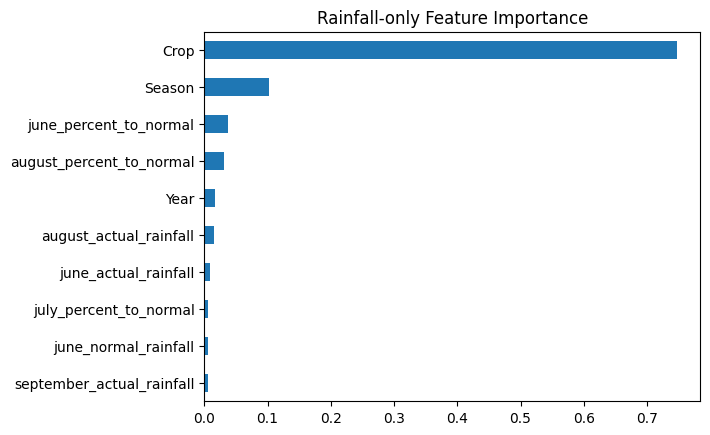

In [59]:
feat_imp.head(10).plot(kind='barh')
plt.title("Rainfall-only Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 2. No-lag model (Crop + Rainfall)

In [78]:
X = df.drop(columns=[
    "Yield",
    "Production",
    "Area",
    "Yield_Lag1",
    "Yield_Lag2",
    "Yield_3yr_Avg",
    "Yield_3yr_Std"
], errors="ignore")
y = df["Yield"]

In [79]:
y.head(3)

0    0.515957
1    0.806548
2    0.250000
Name: Yield, dtype: float64

In [80]:
X.head(10)

,District,Year,Crop,Season,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,ahilyanagar,1998,Arhar_Tur,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,ahilyanagar,1998,Bajra,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,ahilyanagar,1998,Castor_seed,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
3,ahilyanagar,1998,Cottonlint,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
4,ahilyanagar,1998,Gram,Rabi,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
5,ahilyanagar,1998,Groundnut,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
6,ahilyanagar,1998,Groundnut,Summer,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
7,ahilyanagar,1998,Jowar,Kharif,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
8,ahilyanagar,1998,Jowar,Rabi,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
9,ahilyanagar,1998,Linseed,Rabi,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [81]:
from sklearn.preprocessing import LabelEncoder

for col in ["Crop", "Season", "District"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [82]:
X.columns

Index(['District', 'Year', 'Crop', 'Season', 'june_normal_rainfall',
       'june_actual_rainfall', 'june_percent_to_normal',
       'july_normal_rainfall', 'july_actual_rainfall',
       'july_percent_to_normal', 'august_normal_rainfall',
       'august_actual_rainfall', 'august_percent_to_normal',
       'september_normal_rainfall', 'september_actual_rainfall',
       'september_percent_to_normal'],
      dtype='str')

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [84]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [85]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("R2:", r2)
print("RMSE:", rmse)

R2: 0.9446785258816912
RMSE: 0.8400365234001204


In [86]:
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

Crop                         0.747000
Season                       0.102498
june_percent_to_normal       0.036622
august_percent_to_normal     0.031824
Year                         0.017623
august_actual_rainfall       0.015696
june_actual_rainfall         0.009621
july_percent_to_normal       0.006314
june_normal_rainfall         0.006116
september_actual_rainfall    0.005859
dtype: float64


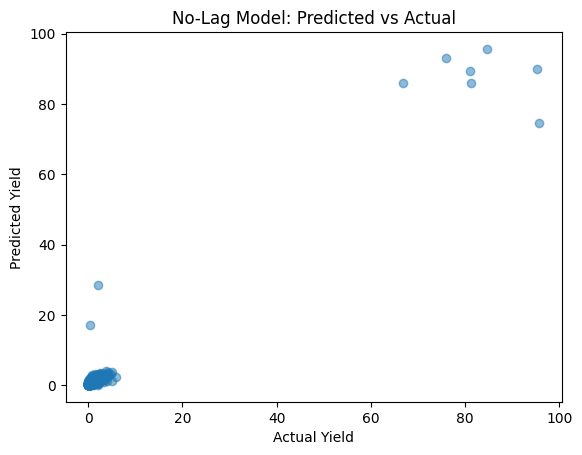

In [87]:
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("No-Lag Model: Predicted vs Actual")
plt.show()

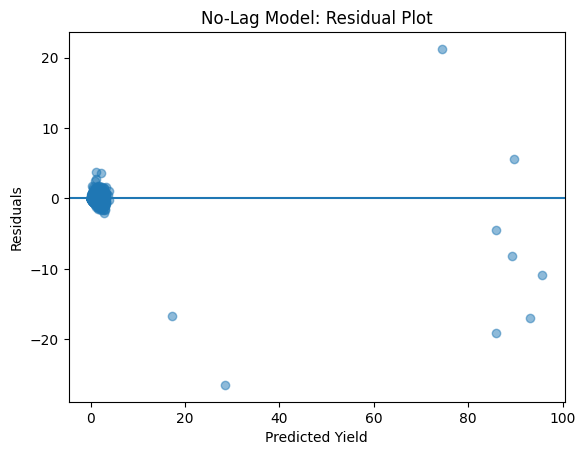

In [88]:
residuals = y_test - preds

plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("No-Lag Model: Residual Plot")
plt.show()

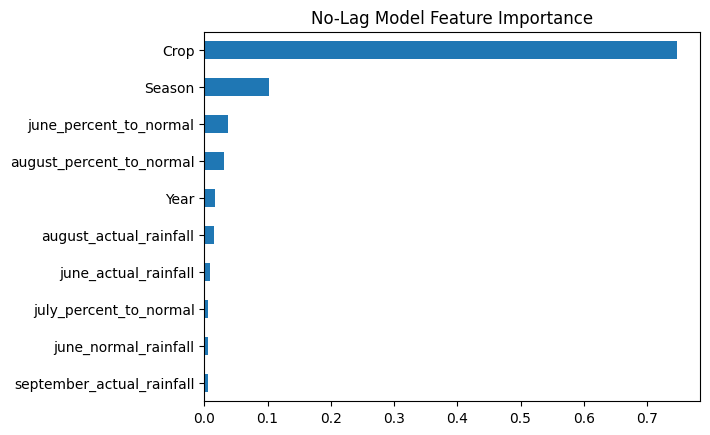

In [89]:
feat_imp.head(10).plot(kind='barh')
plt.title("No-Lag Model Feature Importance")
plt.gca().invert_yaxis()
plt.show()

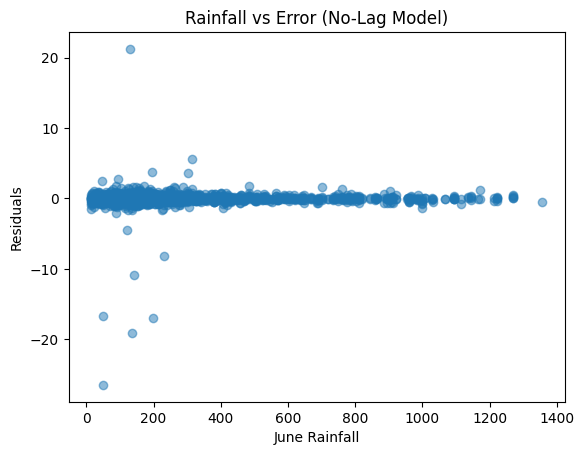

In [90]:
plt.scatter(X_test["june_actual_rainfall"], residuals, alpha=0.5)
plt.xlabel("June Rainfall")
plt.ylabel("Residuals")
plt.title("Rainfall vs Error (No-Lag Model)")
plt.show()

In [ ]:
# 2. Full model (Lag + everything)

In [60]:
X = df.drop(columns=[
    "Yield",
    "Production",   # 🚨 remove
    "Area"          # 🚨 remove
])
y = df["Yield"]

In [61]:
from sklearn.preprocessing import LabelEncoder

for col in ["Crop", "Season", "District"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [63]:
X.head(5)

,District,Year,Crop,Season,Yield_Lag1,Yield_Lag2,Yield_3yr_Avg,Yield_3yr_Std,june_normal_rainfall,june_actual_rainfall,june_percent_to_normal,july_normal_rainfall,july_actual_rainfall,july_percent_to_normal,august_normal_rainfall,august_actual_rainfall,august_percent_to_normal,september_normal_rainfall,september_actual_rainfall,september_percent_to_normal
0,0,1998,0,0,0.357955,0.357955,0.515957,0.0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
1,0,1998,1,0,0.557461,0.557461,0.806548,0.0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
2,0,1998,2,0,0.250000,0.250000,0.250000,0.0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
3,0,1998,3,0,1.644628,1.644628,1.644628,0.0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3
4,0,1998,4,1,0.686242,0.686242,0.686242,0.0,108.2,137.0,126.6,97.5,133.5,136.9,95.4,178.1,186.7,147.0,191.6,130.3


In [64]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [65]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("R2:", r2)
print("RMSE:", rmse)

R2: 0.9876897627164072
RMSE: 0.3962638995072459


In [66]:
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

Yield_3yr_Avg             0.840534
Crop                      0.026356
Year                      0.023377
Yield_Lag1                0.017293
Yield_Lag2                0.016645
Yield_3yr_Std             0.015967
june_actual_rainfall      0.012160
august_actual_rainfall    0.010202
Season                    0.009609
june_percent_to_normal    0.005412
dtype: float64


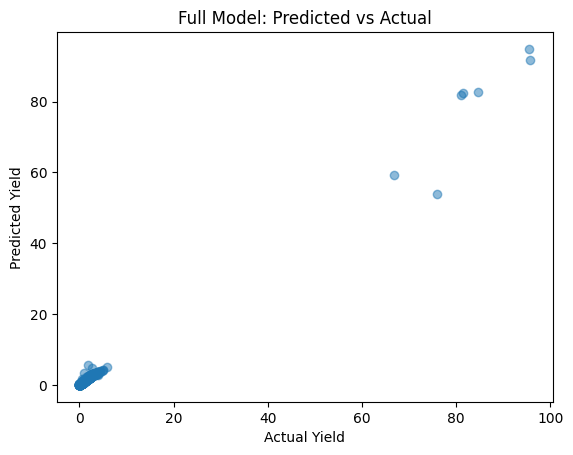

In [67]:
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Full Model: Predicted vs Actual")
plt.show()

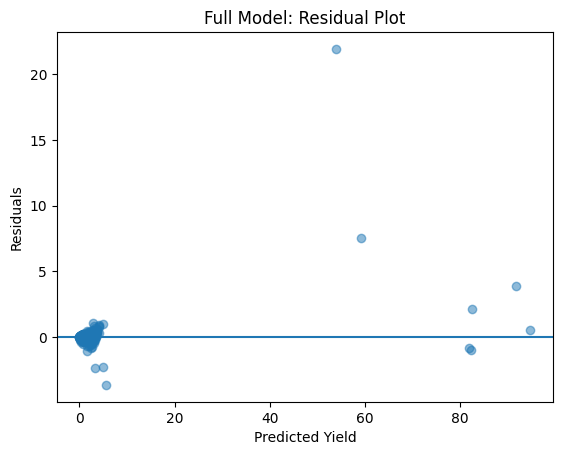

In [68]:
residuals = y_test - preds

plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Full Model: Residual Plot")
plt.show()feat_imp.head(10).plot(kind='barh')
plt.title("Full Model Feature Importance")
plt.gca().invert_yaxis()
plt.show()

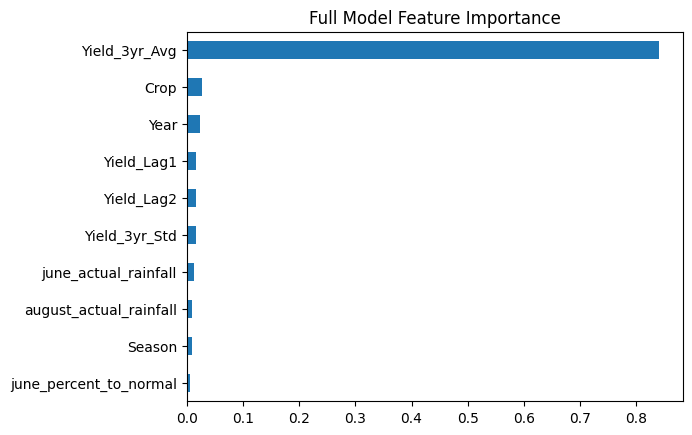

In [69]:
feat_imp.head(10).plot(kind='barh')
plt.title("Full Model Feature Importance")
plt.gca().invert_yaxis()
plt.show()

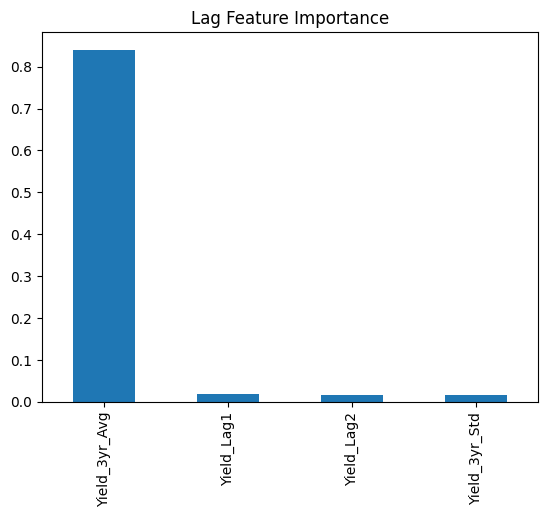

In [70]:
lag_cols = [col for col in feat_imp.index if "Yield" in col]

feat_imp[lag_cols].plot(kind='bar')
plt.title("Lag Feature Importance")
plt.show()

In [26]:
# NOW WE CAN USE SHAP TO PERFORM CAUSAL ANALYSIS AND EXPLAIN THE REASONING IN GREAT DETAIL
# THE BELOW CELLS NEED TO BE RUN ON A GPU-ACCELERATED DEVICE AS IT IS VERY COMPUTATIONALLY HEAVY

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.dependence_plot("june_actual_rainfall", shap_values, X_test)
shap.dependence_plot("august_actual_rainfall", shap_values, X_test)

In [ ]:
import numpy as np

residuals = y_test - preds

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_test["june_actual_rainfall"], residuals)
plt.xlabel("June Rainfall")
plt.ylabel("Residuals")
plt.show()

In [ ]:
plt.scatter(preds, residuals)
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.show()

In [ ]:
X_no_lag = df.drop(columns=[
    "Yield",
    "Production",
    "Area",
    "Yield_Lag1",
    "Yield_Lag2",
    "Yield_3yr_Avg",
    "Yield_3yr_Std"
])
y = df["Yield"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in ["Season", "District"]:
    le = LabelEncoder()
    X_no_lag[col] = le.fit_transform(X_no_lag[col])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("R2:", r2)
print("RMSE:", rmse)

In [ ]:
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

In [29]:
X = df.drop(columns=[
    "Yield",
    "Production",
    "Area",
    "Yield_Lag1",
    "Yield_Lag2",
    "Yield_3yr_Avg",
    "Yield_3yr_Std"
])
y = df["Yield"]

In [30]:
from sklearn.preprocessing import LabelEncoder

for col in ["Crop", "Season", "District"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

preds = model.predict(X_test)

r2 = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.9446785258816913
RMSE: 0.8400365234001202


In [34]:
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feat_imp.head(10))

Crop                         0.747000
Season                       0.102498
june_percent_to_normal       0.036622
august_percent_to_normal     0.031824
Year                         0.017623
august_actual_rainfall       0.015696
june_actual_rainfall         0.009621
july_percent_to_normal       0.006314
june_normal_rainfall         0.006116
september_actual_rainfall    0.005859
dtype: float64


In [37]:
# this one cell below also needs to be run on a gpu accelerated device


In [ ]:
import shap

# take small sample
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

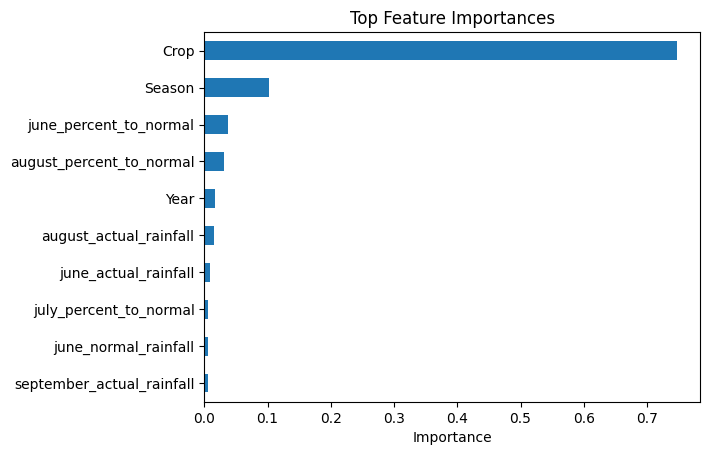

In [38]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind='barh')
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()